Note: Using the same codes in assignment 01,02. However, the graphical representations are not included as it's been checked in assignment 01 already.

In [122]:
!pip install mlflow

Defaulting to user installation because normal site-packages is not writeable

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t


  Obtaining dependency information for mlflow from https://files.pythonhosted.org/packages/40/d2/b2730852278ca62a356c44482a65c9401869418cc2a038654f17f056df9b/mlflow-3.16.0-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/50.0 kB ? eta -:--:--
     -------------------------------------- 50.0/50.0 kB 846.3 kB/s eta 0:00:00
  Obtaining dependency information for mlflow-skinny==3.16.0 from https://files.pythonhosted.org/packages/c0/97/047bfd7004596a6a509030c5520a13f8a31be8c51926c577702026902367/mlflow_skinny-3.16.0-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/50.9 kB ? eta -:--:--
     ---------------------------------------- 50.9/50.9 kB 2.5 MB/s eta 0:00:00
  Obtaining dependency information for mlflow-tracing==3.16.0 from https://files.pythonhosted.org/packages/d3/e4/486d48d96fcb3957f2811e34d17fa21c7d3451eb4b41231832c9f05b6959/mlflow_tracing-3.16.0-py3-none-any.whl.metadata
  Obtaining dependency information for Flask-CORS<7 fro

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mlflow

In [2]:
df=pd.read_csv("Cars.csv") #loading data set

In [3]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [74]:
df.shape #no.of columns and rows of data set

(8128, 13)

In [75]:
df.columns #features

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [76]:
df.describe() #descriptive stats

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [4]:
df['owner'].unique() #checking the components 

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [5]:
df['owner']=df['owner'].map({'First Owner':1, 'Second Owner':2, 'Third Owner':3,
       'Fourth & Above Owner':4, 'Test Drive Car':5}) #assigning new values 

In [5]:
df['fuel'].value_counts()

Diesel    4402
Petrol    3631
CNG         57
LPG         38
Name: fuel, dtype: int64

In [6]:
df = df[(df['fuel']!='CNG')&(df['fuel']!='LPG')]

In [7]:
df['fuel'].value_counts() #confirmation of deletion 

Diesel    4402
Petrol    3631
Name: fuel, dtype: int64

In [8]:
split=df['mileage'].str.split()
split.head()

0     [23.4, kmpl]
1    [21.14, kmpl]
2     [17.7, kmpl]
3     [23.0, kmpl]
4     [16.1, kmpl]
Name: mileage, dtype: object

In [9]:
df['mileage']=split.str[0].astype(float)

In [10]:
df['mileage'].head() #confirmation of cleaning

0    23.40
1    21.14
2    17.70
3    23.00
4    16.10
Name: mileage, dtype: float64

In [13]:
split2=df['engine'].str.split()
split2

0       [1248, CC]
1       [1498, CC]
2       [1497, CC]
3       [1396, CC]
4       [1298, CC]
           ...    
8123    [1197, CC]
8124    [1493, CC]
8125    [1248, CC]
8126    [1396, CC]
8127    [1396, CC]
Name: engine, Length: 8033, dtype: object

In [15]:
df['engine']=split2.str[0].astype(float)
df['engine'].head() #confirmation of cleaning

0    1248.0
1    1498.0
2    1497.0
3    1396.0
4    1298.0
Name: engine, dtype: float64

In [16]:
split3=df['max_power'].str.split()
split3

0           [74, bhp]
1       [103.52, bhp]
2           [78, bhp]
3           [90, bhp]
4         [88.2, bhp]
            ...      
8123     [82.85, bhp]
8124       [110, bhp]
8125      [73.9, bhp]
8126        [70, bhp]
8127        [70, bhp]
Name: max_power, Length: 8033, dtype: object

In [17]:
df['max_power']=split3.str[0].astype(float)
df['max_power'].head() #confirmation of cleaning

0     74.00
1    103.52
2     78.00
3     90.00
4     88.20
Name: max_power, dtype: float64

In [18]:
split4=df['name'].str.split()
split4

0              [Maruti, Swift, Dzire, VDI]
1       [Skoda, Rapid, 1.5, TDI, Ambition]
2            [Honda, City, 2017-2020, EXi]
3           [Hyundai, i20, Sportz, Diesel]
4              [Maruti, Swift, VXI, BSIII]
                       ...                
8123                 [Hyundai, i20, Magna]
8124            [Hyundai, Verna, CRDi, SX]
8125           [Maruti, Swift, Dzire, ZDi]
8126                   [Tata, Indigo, CR4]
8127                   [Tata, Indigo, CR4]
Name: name, Length: 8033, dtype: object

In [19]:
df['name']=split4.str[0]
df['name'].head() #confirmation of cleaning

0     Maruti
1      Skoda
2      Honda
3    Hyundai
4     Maruti
Name: name, dtype: object

In [20]:
df = df.drop('torque', axis=1)

In [18]:
df.columns #confirmation 

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats'],
      dtype='object')

In [21]:
df['owner'].value_counts()

1    5238
2    2073
3     547
4     170
5       5
Name: owner, dtype: int64

In [22]:
df=df[df['owner']!=5]
df['owner'].value_counts() #confirmation

1    5238
2    2073
3     547
4     170
Name: owner, dtype: int64

In [23]:
df.rename(columns={'name':'brand'},inplace=True)
df.head()

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,Maruti,2014,450000,145500,Diesel,Individual,Manual,1,23.40,1248.0,74.00,5.0
1,Skoda,2014,370000,120000,Diesel,Individual,Manual,2,21.14,1498.0,103.52,5.0
2,Honda,2006,158000,140000,Petrol,Individual,Manual,3,17.70,1497.0,78.00,5.0
3,Hyundai,2010,225000,127000,Diesel,Individual,Manual,1,23.00,1396.0,90.00,5.0
4,Maruti,2007,130000,120000,Petrol,Individual,Manual,1,16.10,1298.0,88.20,5.0


In [24]:
df['fuel']=df['fuel'].map({'Diesel':0,'Petrol':1}) #encode to cal correlation
df['fuel'].value_counts()

0    4401
1    3627
Name: fuel, dtype: int64

In [25]:
df['transmission']=df['transmission'].map({'Manual':0,'Automatic':1}) #encode to cal correlation
df['transmission'].value_counts()

0    6982
1    1046
Name: transmission, dtype: int64

In [85]:
df['brand'].value_counts()

Maruti           2378
Hyundai          1393
Mahindra          772
Tata              733
Toyota            488
Honda             466
Ford              397
Chevrolet         228
Renault           228
Volkswagen        185
BMW               120
Skoda             105
Nissan             81
Jaguar             71
Volvo              67
Datsun             65
Mercedes-Benz      54
Fiat               47
Audi               37
Lexus              34
Jeep               31
Mitsubishi         14
Force               6
Land                6
Isuzu               5
Kia                 4
Ambassador          4
Daewoo              3
MG                  3
Ashok               1
Opel                1
Peugeot             1
Name: brand, dtype: int64

In [32]:
labels=[0, 1, 2, 3]
df['price_class'] = pd.cut(df['selling_price'], bins=4, labels=[0, 1, 2, 3])#classify to 4 classes

In [33]:
df.head()#check

,brand,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,price_class
0,Maruti,2014,450000,145500,0,Individual,0,1,23.40,1248.0,74.00,5.0,0
1,Skoda,2014,370000,120000,0,Individual,0,2,21.14,1498.0,103.52,5.0,0
2,Honda,2006,158000,140000,1,Individual,0,3,17.70,1497.0,78.00,5.0,0
3,Hyundai,2010,225000,127000,0,Individual,0,1,23.00,1396.0,90.00,5.0,0
4,Maruti,2007,130000,120000,1,Individual,0,1,16.10,1298.0,88.20,5.0,0


In [34]:
df['price_class'].value_counts()#check

0    7732
1     182
2     113
3       1
Name: price_class, dtype: int64

This not gonna be usefull as classes have huge differences. Hence trying another method

In [35]:
df['price_class'] = pd.qcut(df['selling_price'], q=4, labels=labels)#method2

In [36]:
df['price_class'].value_counts()#check

0    2050
1    2044
3    1991
2    1943
Name: price_class, dtype: int64

In [67]:
X = df[['max_power', 'transmission', 'brand']]
y = df['price_class']

In [68]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=30) #split data

In [70]:
X_train[['max_power', 'transmission','brand']].isna().sum()

max_power       142
transmission      0
brand             0
dtype: int64

In [71]:
X_test[['max_power', 'transmission','brand']].isna().sum()

max_power       66
transmission     0
brand            0
dtype: int64

In [72]:
y_train.isna().sum()

0

In [73]:
y_test.isna().sum()

0

In [74]:
X_train['max_power'].fillna(X_train['max_power'].median(),inplace=True) #train set

In [75]:
X_test['max_power'].fillna(X_train['max_power'].median(),inplace=True) #using train in test set

In [76]:
X_train['max_power'].isna().sum() #checking

0

In [77]:
X_test['max_power'].isna().sum() #checking

0

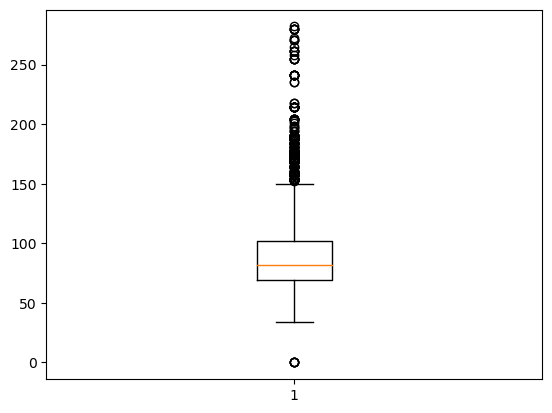

In [78]:
plt.boxplot(X_train['max_power']) #outlier detection other two are encoded features could not consider as real continuous numericals
plt.show()

In [79]:
#defining function for detecting outliers in max power

def outliers(position,data=X_train):
    Q3, Q1 = np.percentile(data[position], [75, 25])
    IQR = Q3 - Q1  #calculating IQR using quartiles
    
    minimum = Q1 - (1.5*IQR) #calculating boundries 
    maximum = Q3 + (1.5*IQR)
    
    outliers = len(np.where((data[position] > maximum) | (data[position] < minimum))[0]) #calculating values outside the boundries i.e. outliers
    
    outliers_percentage = round(outliers/len(data[position])*100, 2) #calculating number of outliers as a percentage of the respective dataset
    
    if(outliers > 0):
        print('Outliers: {}'.format(outliers))
        print('Outliers Percentage out of total: {}%'.format(outliers_percentage)) #print 
    

In [80]:
outliers('max_power')

Outliers: 403
Outliers Percentage out of total: 7.17%


In [81]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
X_train['brand'] = le.fit_transform(X_train['brand'])
X_test['brand'] = le.transform(X_test['brand'])

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train['max_power'] = scaler.fit_transform(X_train[['max_power']])
X_test['max_power'] = scaler.transform(X_test[['max_power']])  #scaling as features are in different scales

In [83]:
#updates on multinomial logistic-regression

intercept = np.ones((X_train.shape[0], 1))
X_train = np.concatenate((intercept, X_train), axis=1)

intercept = np.ones((X_test.shape[0], 1))
X_test = np.concatenate((intercept, X_test), axis=1)

In [84]:
k = len(set(y))
m = X_train.shape[0]
n = X_train.shape[1]

Y_train_encoded = np.zeros((m, k))

for each_class in range(k):
    cond = y_train == each_class
    Y_train_encoded[np.where(cond), each_class] = 1

In [92]:
class RidgePenalty: #from notebook for task 2
    
    def __init__(self, l):
        self.l = l   
        
    def __call__(self, theta):
        return self.l * np.sum(np.square(theta))
        
    def derivation(self, theta):
        return self.l * 2 * theta

In [93]:
#updates on logistic-regression function

class LogisticRegression:
    
    def __init__(self, k, n, method, alpha = 0.001, max_iter=5000,regularization=None):
        self.k = k
        self.n = n
        self.alpha = alpha
        self.max_iter = max_iter
        self.method = method
        self.regularization = regularization #for task 2 for the option for the user
    
    def fit(self, X, Y):
        self.W = np.random.rand(self.n, self.k)
        self.losses = []
        
        if self.method == "batch":
            start_time = time.time()
            for i in range(self.max_iter):
                loss, grad =  self.gradient(X, Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        elif self.method == "minibatch":
            start_time = time.time()
            batch_size = int(0.3 * X.shape[0])
            for i in range(self.max_iter):
                ix = np.random.randint(0, X.shape[0]) #<----with replacement
                batch_X = X[ix:ix+batch_size]
                batch_Y = Y[ix:ix+batch_size]
                loss, grad = self.gradient(batch_X, batch_Y)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        elif self.method == "sto":
            start_time = time.time()
            list_of_used_ix = []
            for i in range(self.max_iter):
                idx = np.random.randint(X.shape[0])
                while i in list_of_used_ix:
                    idx = np.random.randint(X.shape[0])
                X_train = X[idx, :].reshape(1, -1)
                Y_train = Y[idx]
                loss, grad = self.gradient(X_train, Y_train)
                self.losses.append(loss)
                self.W = self.W - self.alpha * grad
                
                list_of_used_ix.append(i)
                if len(list_of_used_ix) == X.shape[0]:
                    list_of_used_ix = []
                if i % 500 == 0:
                    print(f"Loss at iteration {i}", loss)
            print(f"time taken: {time.time() - start_time}")
            
        else:
            raise ValueError('Method must be one of the followings: "batch", "minibatch" or "sto".')
        
        
    def gradient(self, X, Y):
        m = X.shape[0]
        h = self.h_theta(X, self.W)
        loss = - np.sum(Y*np.log(h)) / m
        error = h - Y
        grad = self.softmax_grad(X, error)
        
        if self.regularization is not None: #for task 2 choice for penalty or not
            loss = loss + self.regularization(self.W)
            grad = grad + self.regularization.derivation(self.W)
        
        return loss, grad

    def softmax(self, theta_t_x):
        return np.exp(theta_t_x) / np.sum(np.exp(theta_t_x), axis=1, keepdims=True)

    def softmax_grad(self, X, error):
        return  X.T @ error

    def h_theta(self, X, W):
        '''
        Input:
            X shape: (m, n)
            w shape: (n, k)
        Returns:
            yhat shape: (m, k)
        '''
        return self.softmax(X @ W)
    def predict(self, X_test):
        return np.argmax(self.h_theta(X_test, self.W), axis=1)
    
    def plot(self):
        plt.plot(np.arange(len(self.losses)) , self.losses, label = "Train Losses")
        plt.title("Losses")
        plt.xlabel("epoch")
        plt.ylabel("losses")
        plt.legend()
    
    def accuracy(self, y_true, y_pred):  #adding accuracy
        correct_pred = np.sum(y_true == y_pred)
        return correct_pred / len(y_true)
    
    def precision(self, y_true, y_pred): #adding precision
        precision_score = []
    
        for c in range(self.k):
            TP = np.sum((y_true == c) & (y_pred == c))
            FP = np.sum((y_true != c) & (y_pred == c))
            precision_c = TP / (TP + FP) if (TP + FP) != 0 else 0
            precision_score.append(precision_c)
        return precision_score  
        
    def recall(self, y_true, y_pred): #adding recall
        recall_score = []

        for c in range(self.k):
            TP = np.sum((y_true == c) & (y_pred == c))
            FN = np.sum((y_true == c) & (y_pred != c))
            recall_c = TP / (TP + FN) if (TP + FN) != 0 else 0
            recall_score.append(recall_c)
        return recall_score
        
    def f1_score(self, y_true, y_pred):  #adding f1 
        precision_score = self.precision(y_true, y_pred)
        recall_score = self.recall(y_true, y_pred)
        f1_score = []

        for c in range(self.k):
            precision_c = precision_score[c]
            recall_c = recall_score[c]
            f1_c = 2 * precision_c * recall_c / (precision_c + recall_c) if (precision_c + recall_c) != 0 else 0
            f1_score.append(f1_c)  
        return f1_score
    
    def macro_precision(self, y_true, y_pred):  #adding macro precision
        precision_score = self.precision(y_true, y_pred)
        return np.mean(precision_score)
    
    def macro_recall(self, y_true, y_pred):#adding macro recall
        recall_score = self.recall(y_true, y_pred)
        return np.mean(recall_score)
    
    def macro_f1(self, y_true, y_pred):  #adding macro f1
        f1_score = self.f1_score(y_true, y_pred)
        return np.mean(f1_score)
    
    def weighted_precision(self, y_true, y_pred):  #adding weighted precision
        precision_score = self.precision(y_true, y_pred)
        weighted_sum = 0
    
        for c in range(self.k):
            weight = np.sum(y_true == c) / len(y_true)
            weighted_sum += weight * precision_score[c]
        return weighted_sum
    
    def weighted_recall(self, y_true, y_pred):  #adding weighted recall
        recall_score = self.recall(y_true, y_pred)
        weighted_sum = 0
    
        for c in range(self.k):
             weight = np.sum(y_true == c) / len(y_true)
             weighted_sum += weight * recall_score[c]       
        return weighted_sum
    
    def weighted_f1(self, y_true, y_pred):  #adding weighted f1
        f1_score = self.f1_score(y_true, y_pred)
        weighted_sum = 0

        for c in range(self.k):
            weight = np.sum(y_true == c) / len(y_true)
            weighted_sum += weight * f1_score[c]
        return weighted_sum
    
    
  

In [57]:
import time

Loss at iteration 0 5.810382941879972
Loss at iteration 500 1.3054301809202355
Loss at iteration 1000 1.281385437077507
Loss at iteration 1500 1.251281708310813
Loss at iteration 2000 1.2363255319251445
Loss at iteration 2500 1.2338587011257531
Loss at iteration 3000 1.208060933870928
Loss at iteration 3500 1.208058440737322
Loss at iteration 4000 1.2094105415802494
Loss at iteration 4500 1.187870205799499
time taken: 1.558699131011963


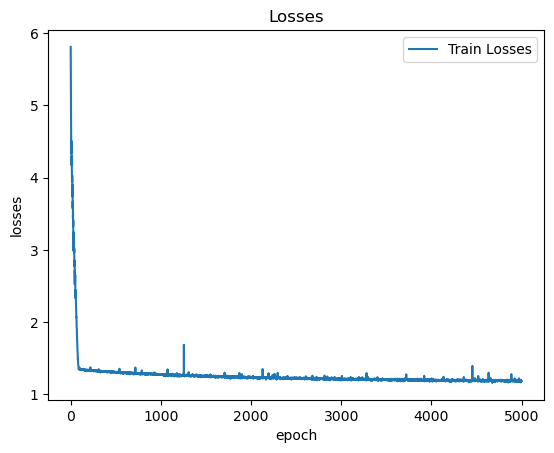

In [89]:
model = LogisticRegression(k, X_train.shape[1], 'minibatch',alpha=0.000001) ## train multinomial logistic regression using minibatch gradient descent. codes used from lecture notebook. setup alpha as well to make results more accurate
model.fit(X_train, Y_train_encoded)
yhat = model.predict(X_test)
model.plot()

In [90]:
from sklearn.metrics import classification_report

print('Accuracy:', model.accuracy(y_test, yhat))
print('Precision:', model.precision(y_test, yhat))
print('Recall:', model.recall(y_test, yhat))
print('F1:', model.f1_score(y_test, yhat))

print('Macro Precision:', model.macro_precision(y_test, yhat))
print('Macro Recall:', model.macro_recall(y_test, yhat))
print('Macro F1:', model.macro_f1(y_test, yhat))

print('Weighted Precision:', model.weighted_precision(y_test, yhat))
print('Weighted Recall:', model.weighted_recall(y_test, yhat))
print('Weighted F1:', model.weighted_f1(y_test, yhat))

print('Sklearn Results:')
print(classification_report(y_test, yhat))

Accuracy: 0.42216687422166876
Precision: [0.4440677966101695, 0.2857142857142857, 0.3373493975903614, 0.5853658536585366]
Recall: [0.6528239202657807, 0.38688524590163936, 0.046357615894039736, 0.6070826306913997]
F1: [0.5285810356422327, 0.32869080779944293, 0.08151382823871907, 0.5960264900662251]
Macro Precision: 0.4131243333933383
Macro Recall: 0.42328735318821487
Macro F1: 0.38370304043665493
Weighted Precision: 0.4119948174384087
Weighted Recall: 0.42216687422166876
Weighted F1: 0.382476229588934
Sklearn Results:
              precision    recall  f1-score   support

           0       0.44      0.65      0.53       602
           1       0.29      0.39      0.33       610
           2       0.34      0.05      0.08       604
           3       0.59      0.61      0.60       593

    accuracy                           0.42      2409
   macro avg       0.41      0.42      0.38      2409
weighted avg       0.41      0.42      0.38      2409



Accuracy: 0.4222 ---> sklearn reults: 0.42
Macro precision: 0.4131 ---> sklearn reults: 0.41
Macro recall: 0.4233 ---> sklearn reults: 0.42
Macro F1: 0.3837 ---> sklearn reults: 0.38
Weighted precision: 0.4120 ---> sklearn reults: 0.41
Weighted recall: 0.4222 ---> sklearn reults: 0.42
Weighted F1: 0.3825 ---> sklearn reults: 0.38

As per above it can be confirmed that both implementations are close.

support: number of actual observations belonging to each class in the test dataset

In [94]:
ridge_penalty = RidgePenalty(l=0.1)
ridge_model = LogisticRegression(k, X_train.shape[1], 'minibatch', alpha=0.000001, regularization=ridge_penalty)

Loss at iteration 0 3.6776064046660233
Loss at iteration 500 1.6754749481332083
Loss at iteration 1000 1.6309930726222004
Loss at iteration 1500 1.6123440089282777
Loss at iteration 2000 1.5979431593085784
Loss at iteration 2500 1.5925941740644163
Loss at iteration 3000 1.5912129062470426
Loss at iteration 3500 1.5894960804373952
Loss at iteration 4000 1.6015637691999856
Loss at iteration 4500 1.6059221793887064
time taken: 1.6436522006988525


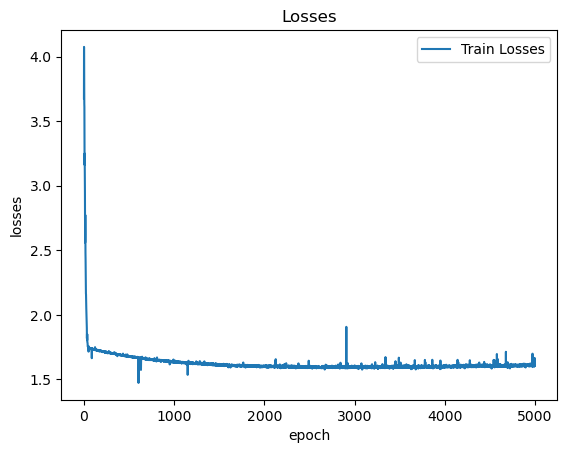

In [95]:
ridge_model.fit(X_train, Y_train_encoded)
ridge_yhat = ridge_model.predict(X_test)
ridge_model.plot()

In [96]:
print('Ridge Accuracy:', ridge_model.accuracy(y_test, ridge_yhat))
print(classification_report(y_test, ridge_yhat))

Ridge Accuracy: 0.41012868410128683
              precision    recall  f1-score   support

           0       0.38      0.66      0.48       602
           1       0.28      0.22      0.25       610
           2       0.40      0.13      0.19       604
           3       0.56      0.64      0.59       593

    accuracy                           0.41      2409
   macro avg       0.40      0.41      0.38      2409
weighted avg       0.40      0.41      0.38      2409



In [98]:
import mlflow

mlflow.set_tracking_uri('http://127.0.0.1:5000')
mlflow.set_experiment(experiment_name='st127034-a3')

2026/10/02 00:16:31 INFO mlflow.tracking.fluent: Experiment with name 'st127034-a3' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1790874991241, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790874991241, lifecycle_stage='active', name='st127034-a3', tags={}, trace_location=None, workspace='default'>

In [100]:
#without ridge
mlflow.sklearn.log_model(model, name='model', signature=signature, serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE)
mlflow.end_run()

2026/10/02 00:22:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LogisticRegression_NoRidge at: http://127.0.0.1:5000/#/experiments/1/runs/a3a4053c69364b08aa2dc93eb9a1d954
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [101]:
#with ridge
import mlflow.sklearn

mlflow.start_run(run_name='LogisticRegression_Ridge')
mlflow.log_params({'method': 'minibatch', 'alpha': 0.000001, 'max_iter': 5000, 'regularization': 'Ridge', 'lambda': 0.1})

mlflow.log_metric('accuracy', ridge_model.accuracy(y_test, ridge_yhat))
mlflow.log_metric('macro_f1', ridge_model.macro_f1(y_test, ridge_yhat))
mlflow.log_metric('weighted_f1', ridge_model.weighted_f1(y_test, ridge_yhat))

ridge_signature = mlflow.models.infer_signature(X_train, ridge_model.predict(X_train))

mlflow.sklearn.log_model(ridge_model, name='model', signature=ridge_signature, serialization_format=mlflow.sklearn.SERIALIZATION_FORMAT_CLOUDPICKLE)

mlflow.end_run()

2026/10/02 00:24:07 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run LogisticRegression_Ridge at: http://127.0.0.1:5000/#/experiments/1/runs/d67ce3094ab64e4eb315dc754a60a6e2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Screenshots:
![pic1](LG_full.png)
![pic2](LG_with_noridge.png)
![pic3](LG_with_ridge.png)

In [102]:
import cloudpickle

with open('best_model.pkl', 'wb') as f:
    cloudpickle.dump(model, f)

In [103]:
%%writefile test_model.py

import numpy as np
import cloudpickle

with open('best_model.pkl', 'rb') as f: model = cloudpickle.load(f)

def test_model_input():
    X_sample = np.array([[1.0, 0.0, 1.0, 0.0]])
    prediction = model.predict(X_sample)
    assert prediction is not None

def test_model_output_shape():
    X_sample = np.array([[1.0, 0.0, 1.0, 0.0]])
    prediction = model.predict(X_sample)
    assert prediction.shape == (1,)

Writing test_model.py


In [104]:
!pytest test_model.py -v

============================= test session starts =============================
platform win32 -- Python 3.11.4, pytest-7.4.0, pluggy-1.0.0 -- C:\ProgramData\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\Kethmi\Documents\classes\ML\Assignment 03
plugins: anyio-4.15.1, dash-4.4.1, Faker-40.39.0
collecting ... collected 2 items

test_model.py::test_model_input PASSED                                   [ 50%]
test_model.py::test_model_output_shape PASSED                            [100%]

============================== 2 passed in 1.96s ==============================


In [105]:
import os
os.makedirs('.github/workflows', exist_ok=True)

In [106]:
%%writefile .github/workflows/test.yml

name: Model Tests

on:
  push:

jobs:
  test:
    runs-on: ubuntu-latest

    steps:
      - name: Checkout repository
        uses: actions/checkout@v4

      - name: Set up Python
        uses: actions/setup-python@v5
        with:
          python-version: '3.11'

      - name: Install dependencies
        run: pip install numpy cloudpickle pytest

      - name: Run unit tests
        run: pytest test_model.py -v

Writing .github/workflows/test.yml


In [107]:
import cloudpickle

with open("scaler_a3.pkl", "wb") as f: cloudpickle.dump(scaler, f)
with open("label_encoder_a3.pkl", "wb") as f: cloudpickle.dump(le, f)

Screenshots
![pic4](Git.png)
![pic5](render.png)